In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
path1 = r"H:\python\analise_de_dados\Tabela5-sem_emprego_2012.csv"
path2 = r"H:\python\analise_de_dados\Tabela5-sem_emprego_2026.csv"
path3 = r"H:\python\analise_de_dados\Tabela 1.1.1.xls"

In [3]:
tab2012 = pd.read_csv(path1, sep = ";", encoding="utf-8", decimal=",")
tab2026 = pd.read_csv(path2, sep = ";", encoding="utf-8", decimal=",")

In [4]:
tab2012 = tab2012.rename(columns= {"Desocupados - homens (2012 T1)" : "Homens 2012"})
tab2012 = tab2012.rename(columns= {"Desocupados - mulheres (2012 T1)" : "Mulheres  2012"})
tab2026 = tab2026.rename(columns= {"Desocupados - homens (2026 T1)" : "Homens 2026"})
tab2026 = tab2026.rename(columns= {"Desocupados - mulheres (2026 T1)" : "Mulheres  2026"})



In [5]:
tab2012

,Sigla,Código,Estado,Homens 2012,Mulheres 2012
0,AC,12,Acre,45.3,54.7
1,AL,27,Alagoas,44.7,55.3
2,AM,13,Amazonas,47.5,52.5
3,AP,16,Amapá,48.1,51.9
4,BA,29,Bahia,43.8,56.2
5,CE,23,Ceará,51.1,48.9
6,DF,53,Distrito Federal,41.0,59.0
7,ES,32,Espírito Santo,46.4,53.6
8,GO,52,Goiás,41.0,59.0
9,MA,21,Maranhão,47.2,52.8


In [6]:
tab2026

,Sigla,Código,Estado,Homens 2026,Mulheres 2026
0,AC,12,Acre,53.2,46.8
1,AL,27,Alagoas,50.7,49.3
2,AM,13,Amazonas,46.8,53.2
3,AP,16,Amapá,51.1,48.9
4,BA,29,Bahia,44.7,55.3
5,CE,23,Ceará,52.7,47.3
6,DF,53,Distrito Federal,47.9,52.1
7,ES,32,Espírito Santo,47.5,52.5
8,GO,52,Goiás,47.5,52.5
9,MA,21,Maranhão,49.1,50.9


In [7]:
comp = tab2012.merge(tab2026, on=["Sigla", "Código", "Estado"], how="inner")
comp

,Sigla,Código,Estado,Homens 2012,Mulheres 2012,Homens 2026,Mulheres 2026
0,AC,12,Acre,45.3,54.7,53.2,46.8
1,AL,27,Alagoas,44.7,55.3,50.7,49.3
2,AM,13,Amazonas,47.5,52.5,46.8,53.2
3,AP,16,Amapá,48.1,51.9,51.1,48.9
4,BA,29,Bahia,43.8,56.2,44.7,55.3
5,CE,23,Ceará,51.1,48.9,52.7,47.3
6,DF,53,Distrito Federal,41.0,59.0,47.9,52.1
7,ES,32,Espírito Santo,46.4,53.6,47.5,52.5
8,GO,52,Goiás,41.0,59.0,47.5,52.5
9,MA,21,Maranhão,47.2,52.8,49.1,50.9


In [8]:
# Lê sem usar a 1ª linha como nome de coluna (senão o título vira "coluna")
bruto = pd.read_excel(path3, engine="xlrd", header=None)

# Linhas 0–7: título/cabeçalho  |  8–40: resultados  |  41+: fonte e notas
indicador_1 = bruto.iloc[8:41].copy()
indicador_1.columns = [
    "uf_regiao",
    "total",
    "total_branca",
    "total_preta_parda",
    "homem_branca",
    "homem_preta_parda",
    "mulher_branca",
    "mulher_preta_parda",
]
indicador_1 = indicador_1.reset_index(drop=True)

# horas são número, não texto
for col in indicador_1.columns[1:]:
    indicador_1[col] = pd.to_numeric(indicador_1[col], errors="coerce")

indicador_1



,uf_regiao,total,total_branca,total_preta_parda,homem_branca,homem_preta_parda,mulher_branca,mulher_preta_parda
0,Brasil,16.985781,16.545930,17.333142,11.705136,11.746330,20.404106,22.037998
1,Norte,16.187037,15.925246,16.256032,11.588653,11.514646,19.295780,20.534188
2,Rondônia,17.014162,16.727733,17.101523,12.111127,12.544080,20.412887,21.061410
3,Acre,13.606903,13.806929,13.541399,10.796120,9.686983,16.130352,16.710754
4,Amazonas,16.807290,15.987545,16.995493,12.233043,12.822584,18.764969,20.716986
5,Roraima,13.639257,13.651755,13.633606,10.814803,10.476601,16.135877,16.560244
6,Pará,16.474268,16.181627,16.560239,11.524306,11.026707,19.835110,21.591144
7,Amapá,13.586656,14.389180,13.415091,11.116821,10.749444,16.648579,15.908487
8,Tocantins,15.815781,15.701788,15.768728,10.733863,11.682616,19.663713,19.629399
9,Nordeste,18.499396,18.151700,18.610911,11.723907,11.848436,22.744666,23.716716


In [9]:
regioes = ["Norte", "Nordeste", "Sudeste", "Sul", "Centro-Oeste"]

estados = indicador_1[~indicador_1["uf_regiao"].isin(["Brasil"] + regioes)]
estados

,uf_regiao,total,total_branca,total_preta_parda,homem_branca,homem_preta_parda,mulher_branca,mulher_preta_parda
2,Rondônia,17.014162,16.727733,17.101523,12.111127,12.544080,20.412887,21.061410
3,Acre,13.606903,13.806929,13.541399,10.796120,9.686983,16.130352,16.710754
4,Amazonas,16.807290,15.987545,16.995493,12.233043,12.822584,18.764969,20.716986
5,Roraima,13.639257,13.651755,13.633606,10.814803,10.476601,16.135877,16.560244
6,Pará,16.474268,16.181627,16.560239,11.524306,11.026707,19.835110,21.591144
7,Amapá,13.586656,14.389180,13.415091,11.116821,10.749444,16.648579,15.908487
8,Tocantins,15.815781,15.701788,15.768728,10.733863,11.682616,19.663713,19.629399
10,Maranhão,16.669614,16.421773,16.708894,11.665173,11.437359,19.881056,20.739589
11,Piauí,17.960366,16.948094,18.231789,12.258324,11.204814,20.494063,23.695440
12,Ceará,19.499293,18.527120,19.882469,12.186936,12.821323,23.019718,24.952274


In [10]:
tab1 = indicador_1.rename(columns= {"uf_regiao" : "Estado"})

In [11]:
tabtotal = comp.merge(tab1, on=["Estado"], how="inner")
tabtotal

,Sigla,Código,Estado,Homens 2012,Mulheres 2012,Homens 2026,Mulheres 2026,total,total_branca,total_preta_parda,homem_branca,homem_preta_parda,mulher_branca,mulher_preta_parda
0,AC,12,Acre,45.3,54.7,53.2,46.8,13.606903,13.806929,13.541399,10.796120,9.686983,16.130352,16.710754
1,AL,27,Alagoas,44.7,55.3,50.7,49.3,20.217129,19.165111,20.560451,12.121839,13.357160,24.093655,25.856637
2,AM,13,Amazonas,47.5,52.5,46.8,53.2,16.807290,15.987545,16.995493,12.233043,12.822584,18.764969,20.716986
3,AP,16,Amapá,48.1,51.9,51.1,48.9,13.586656,14.389180,13.415091,11.116821,10.749444,16.648579,15.908487
4,BA,29,Bahia,43.8,56.2,44.7,55.3,17.849776,17.538007,17.935566,10.551673,10.982808,22.572730,23.217119
5,CE,23,Ceará,51.1,48.9,52.7,47.3,19.499293,18.527120,19.882469,12.186936,12.821323,23.019718,24.952274
6,DF,53,Distrito Federal,41.0,59.0,47.9,52.1,15.096351,15.061306,15.126295,11.377952,10.481279,17.738123,19.307332
7,ES,32,Espírito Santo,46.4,53.6,47.5,52.5,17.111106,16.510610,17.478861,11.798571,12.017589,20.464462,22.196626
8,GO,52,Goiás,41.0,59.0,47.5,52.5,15.186471,14.962622,15.296966,10.636424,10.531883,18.440842,19.587913
9,MA,21,Maranhão,47.2,52.8,49.1,50.9,16.669614,16.421773,16.708894,11.665173,11.437359,19.881056,20.739589


In [12]:

ordem = tabtotal.sort_values("Mulheres  2026")["Estado"]

longo = tabtotal.melt(
    id_vars=["Estado"],
    value_vars=["Mulheres  2012", "Mulheres  2026"],
    var_name="Ano",
    value_name="Participacao_mulheres",
)

longo["Ano"] = longo["Ano"].map(
    {"Mulheres  2012": "2012 T1", "Mulheres  2026": "2026 T1"}
)



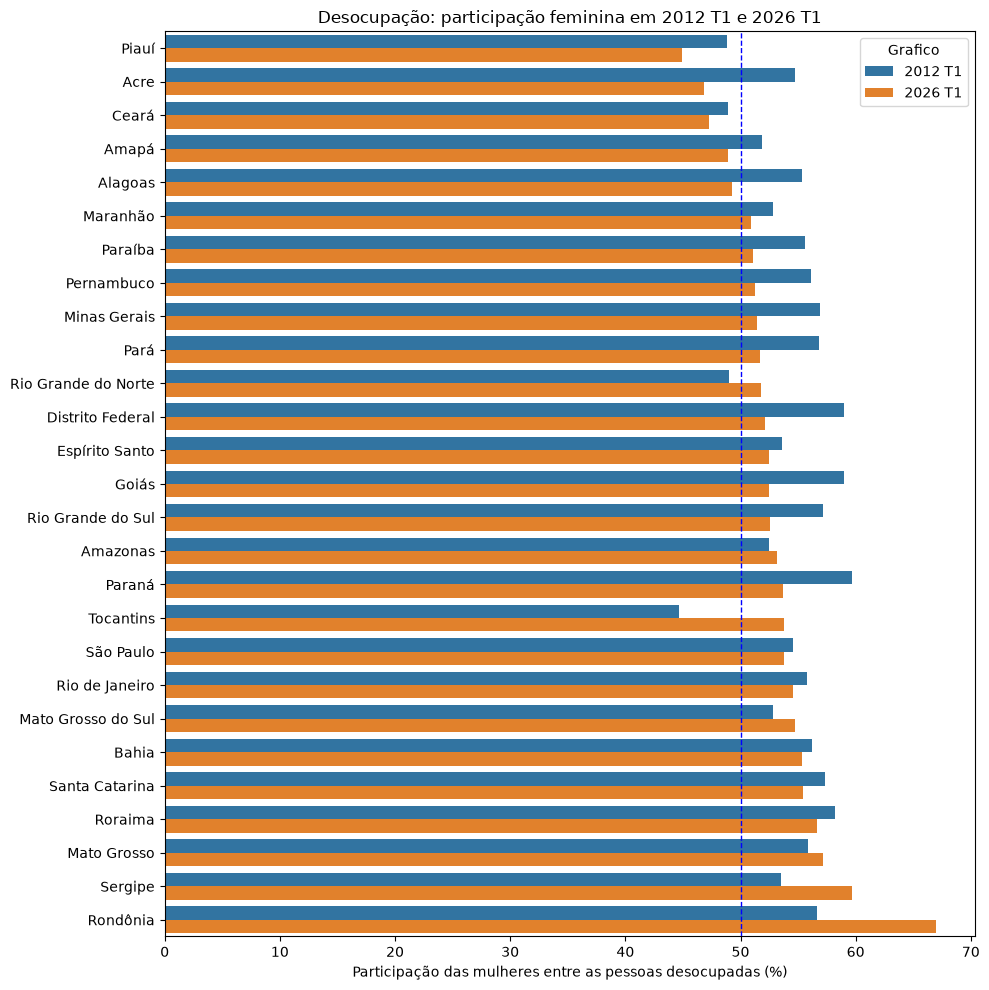

In [13]:
fig, ax = plt.subplots(figsize=(10, 10))

sns.barplot(
    data=longo,
    y="Estado",
    x="Participacao_mulheres",
    hue="Ano",
    order=ordem,
    ax=ax,
)
ax.axvline(50, color="blue", linestyle="--", linewidth=1) 
ax.set_xlabel("Participação das mulheres entre as pessoas desocupadas (%)")
ax.set_ylabel("")
ax.set_title("Desocupação: participação feminina em 2012 T1 e 2026 T1")
ax.legend(title="Grafico")
plt.tight_layout()
plt.show()